# System ID from partial measurement: latent FTNODE vs unstructured latent NODE

**Test case.** Take the Duffing plant with true state $\boldsymbol{x} = (q, \dot q) \in \R^2$ but expose only the partial measurement

$$ 
y(t) = h(\boldsymbol{x}(t)) = q(t),\qquad p = 1 < d = 2. 
$$

We are given the *initial measurement window* $y_{[-\tau:0]}$ but we have no way to recover $\dot q(t)$ at later times — there is no online estimator and no resync. The only training signal is the long sequence $y_{[0:L]}$.

**Duffing Plant System:** The slightly damped double well case: 2 stable + 1 unstable equilibria.

$$
\dot{\boldsymbol{x}}
= \begin{bmatrix} \dot q \\[2pt] \ddot q \end{bmatrix}
= \begin{bmatrix} \dot q \\[2pt] -\delta\,\dot q + q - q^{3} + u \end{bmatrix},
\qquad \delta = 0.2,
$$

equivalently the scalar second-order ODE $\ddot q + \delta\,\dot q - q + q^{3} = u$. At constant forcing $u$ the equilibria satisfy $\dot q = 0$ and $q^{3} - q - u = 0$; for $|u| < 2/(3\sqrt 3) \approx 0.385$ the plant is bistable, with two hyperbolic sinks at $q = \pm 1$ and a saddle at $q = 0$ when $u = 0$.

**Why this is the interesting regime for FTNODE.** When training a sysid model on partial observations, you are forced into long rollouts: there is no $\boldsymbol{x}_t \to \boldsymbol{x}_{t+1}$ teacher-forcing signal beyond what survives in $y$. With an unstructured neural ODE in the latent space, long rollouts during training routinely blow up before they fit anything. A structural prior on the latent dynamics that *guarantees boundedness* (here: the FTNODE contraction $\tfrac12(\boldsymbol{A} + \boldsymbol{A}^\top)\preceq -\sigma_{\min}\boldsymbol{I}$) buys two things at once — (i) bounded gradients during long-horizon training, and (ii) a reduced search space that biases the model toward dynamics with hyperbolic equilibria ($\mathcal{Re}\lambda_i (J(x^*))\neq 0$), which is what a Duffing-class plant actually has.

**Setup.**
1. *Encoder* $\phi : \R^\tau \to \R^m$ lifts a window of the observation into a latent state $\boldsymbol{z}_0$ (here $m \ge d$ — we *over-parameterise* the latent space).
2. *Latent dynamics* $\dot{\boldsymbol{z}} = \boldsymbol{F}_\theta(\boldsymbol{z}, \boldsymbol{u})$. Two variants:
   - **(L-FT)** Latent FTNODE, matrix form: $\boldsymbol{F}_\theta = \boldsymbol{A}_\theta(\boldsymbol{z})(\boldsymbol{z} - \boldsymbol{g}_\theta(\boldsymbol{z}, \boldsymbol{u}))$ with $\boldsymbol{A}_\theta = -(\boldsymbol{L}\boldsymbol{L}^\top + \sigma_{\min}\boldsymbol{I}) + (\boldsymbol{M} - \boldsymbol{M}^\top)$ — same Cholesky+skew parameterisation as the matrix notebook. Symmetric part is uniformly negative-definite by construction.
   - **(L-N)** Plain latent NODE: $\boldsymbol{F}_\theta = \mathrm{MLP}(\boldsymbol{z}, \boldsymbol{u})$, no structural prior, matched parameter budget.
3. *Decoder* $\psi : \R^m \to \R$ is a (small, low-rank) head, $\hat y = \psi(\boldsymbol{z})$.
4. *Loss* is rollout MSE on $y$ over a long horizon $L$ at constant $u$ during training. Train rolls out $L$ steps from $\boldsymbol{z}_0 = \phi(y_{[-\tau:0]})$ and matches $\hat y_{[0:L]}$ to $y_{[0:L]}$.

**What we will look at.**
- Training loss, training stability (does L-N blow up at long $L$?).
- Reconstruction of $y$ on held-out long rollouts.
- Implicit recovery of $\dot q$ via the best linear projection of the latent state (a sanity check that the model has *learned* something representative of the missing coordinate).
- Extrapolation beyond the training horizon.
- Latent norm during rollout (does $\|\boldsymbol{z}\|$ stay bounded? FTNODE: yes by construction).

This is intentionally a *minimum viable* exploration — the goal is to verify the qualitative claim that the FTNODE structural prior pays off in the partial-observation regime.

In [1]:
import sys, pathlib, time
ROOT = pathlib.Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as Fnn



DUFFING MODEL

In [2]:

from __future__ import annotations

from dataclasses import dataclass

import numpy as np


@dataclass(frozen=True)
class DuffingParams:
    delta: float = 0.2  # damping; small enough that approach is underdamped


def F(x: np.ndarray, u: float | np.ndarray, params: DuffingParams) -> np.ndarray:
    """Plant vector field. x has shape (..., 2); u is scalar (or shape (...,))."""
    x1 = x[..., 0]
    x2 = x[..., 1]
    f1 = x2
    f2 = -params.delta * x2 - x1**3 + x1 + np.asarray(u)
    return np.stack([f1, f2], axis=-1)


def DxF(x: np.ndarray, u: float, params: DuffingParams) -> np.ndarray:
    """Jacobian D_x F at a single state x of shape (2,)."""
    x1 = x[..., 0]
    return np.array(
        [
            [0.0, 1.0],
            [1.0 - 3.0 * x1**2, -params.delta],
        ]
    )


def DuF(x: np.ndarray, u: float, params: DuffingParams) -> np.ndarray:
    """Jacobian D_u F at state x. Returns shape (2,)."""
    return np.array([0.0, 1.0])


def equilibria(u: float) -> list[np.ndarray]:
    """Equilibria of the autonomous Duffing system at fixed u.

    Solve x1**3 - x1 - u = 0 (with x2 = 0). Returns the real roots as
    states (x1, 0). For |u| < 2/(3*sqrt(3)) ~= 0.385 there are three roots:
    two sinks (outer roots) and one saddle (middle root). Sink labelled by
    sign of x1.
    """
    coeffs = [1.0, 0.0, -1.0, -float(u)]
    roots = np.roots(coeffs)
    real_roots = sorted(r.real for r in roots if abs(r.imag) < 1e-9)
    return [np.array([r, 0.0]) for r in real_roots]


def sinks(u: float) -> dict[str, np.ndarray]:
    """Return the two hyperbolic sinks (left/right) when bistable.

    Falls back to a single sink when u is outside the bistable window.
    """
    eqs = equilibria(u)
    if len(eqs) == 3:
        return {"left": eqs[0], "right": eqs[2]}
    return {"only": eqs[0]}


def simulate(
    x0: np.ndarray,
    u_of_t,
    params: DuffingParams,
    t_grid: np.ndarray,
) -> np.ndarray:
    """Integrate the plant on t_grid with control u_of_t (callable t -> u).

    Uses RK4 with the t_grid spacing. Returns array of shape (T, 2).
    """
    xs = np.empty((len(t_grid), 2))
    xs[0] = x0
    for i in range(len(t_grid) - 1):
        t = t_grid[i]
        h = t_grid[i + 1] - t
        x = xs[i]
        u1 = u_of_t(t)
        u2 = u_of_t(t + 0.5 * h)
        u4 = u_of_t(t + h)
        k1 = F(x, u1, params)
        k2 = F(x + 0.5 * h * k1, u2, params)
        k3 = F(x + 0.5 * h * k2, u2, params)
        k4 = F(x + h * k3, u4, params)
        xs[i + 1] = x + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    return xs


In [3]:

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

params = DuffingParams(delta=0.2)
print('open-loop sinks at u=0:', sinks(0.0))

device: cpu
open-loop sinks at u=0: {'left': array([-1.,  0.]), 'right': array([1., 0.])}


## 1. Generate partial-observation data

Long rollouts of the Duffing plant under random piecewise-constant $u$. We keep the full state for evaluation but expose only $y = q$ to training. The training signal is structured as `(window, u, y_long)` triples:
- `window`: $\tau$ samples of $y$ before $t = 0$, used by the encoder to build $\boldsymbol{z}_0$.
- `u`: the constant control on the rollout.
- `y_long`: the next $L$ observations (training target).

We deliberately use a *long* horizon ($L = 200$ steps at $h = 0.05$, so $T = 10$) — long enough that an unstructured latent NODE is likely to blow up during training before it fits.

train: window torch.Size([512, 8]) u torch.Size([512]) y_long torch.Size([512, 201])
val  : window torch.Size([64, 8]) u torch.Size([64]) y_long torch.Size([64, 601]) (extrapolation horizon)


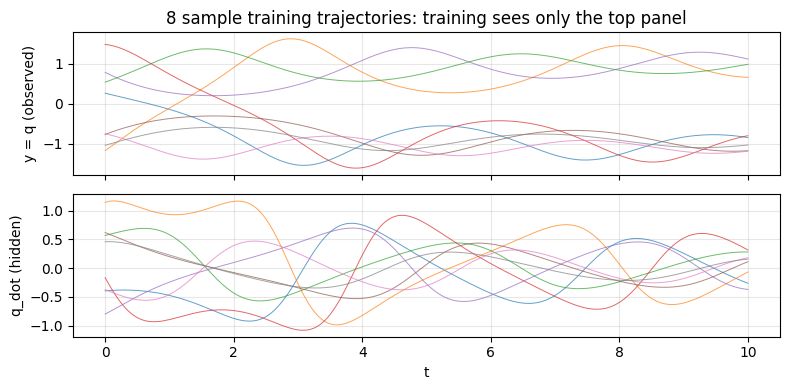

In [4]:
h_dt   = 0.05      # integration timestep
tau    = 8         # encoder window length
L      = 200       # training rollout length (T = 10)
L_eval = 600       # eval horizon (T = 30) -> tests extrapolation
u_range = 0.25
x_range = 1.6

def make_dataset(n_traj=512, L=L, tau=tau, h=h_dt, seed=0):
    rng = np.random.default_rng(seed)
    # Total trajectory length: tau (warmup) + L (rollout target) + 1
    Ttot = tau + L + 1
    t_grid = np.arange(Ttot) * h
    Xfull = np.zeros((n_traj, Ttot, 2), dtype=np.float32)
    U     = np.zeros((n_traj,), dtype=np.float32)
    for i in range(n_traj):
        # Random IC anywhere reasonable (both basins, with some velocity).
        x0 = np.array([
            rng.uniform(-x_range, x_range),
            rng.uniform(-1.0, 1.0),
        ], dtype=np.float64)
        u  = float(rng.uniform(-u_range, u_range))
        traj = simulate(x0, lambda t, _u=u: _u, params, t_grid)
        Xfull[i] = traj.astype(np.float32)
        U[i] = u
    Y    = Xfull[..., 0]                 # observed: q only
    Wind = Y[:, :tau]                    # encoder window
    Yl   = Y[:, tau:tau + L + 1]         # rollout target (L+1 samples)
    Xl   = Xfull[:, tau:tau + L + 1]     # full state for evaluation
    return (
        torch.from_numpy(Wind),
        torch.from_numpy(U),
        torch.from_numpy(Yl),
        torch.from_numpy(Xl),
    )

Wtr, Utr, Ytr, Xtr = make_dataset(n_traj=512, L=L, seed=0)
Wva, Uva, Yva, Xva = make_dataset(n_traj=64,  L=L_eval, seed=1)
print('train: window', Wtr.shape, 'u', Utr.shape, 'y_long', Ytr.shape)
print('val  : window', Wva.shape, 'u', Uva.shape, 'y_long', Yva.shape, '(extrapolation horizon)')

fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
tline = np.arange(L + 1) * h_dt
for i in range(8):
    axes[0].plot(tline, Ytr[i].numpy(), lw=0.7, alpha=0.7)
    axes[1].plot(tline, Xtr[i, :, 1].numpy(), lw=0.7, alpha=0.7)
axes[0].set_ylabel('y = q (observed)'); axes[0].grid(alpha=0.3)
axes[1].set_ylabel('q_dot (hidden)'); axes[1].set_xlabel('t'); axes[1].grid(alpha=0.3)
axes[0].set_title('8 sample training trajectories: training sees only the top panel')
plt.tight_layout(); plt.show()

## 2. Latent state-space models

Both models share encoder/decoder; only the latent dynamics differ.

- **Encoder** `phi(window) -> z0`: small MLP from $\R^\tau$ to $\R^m$, with a `tanh` head scaled by $R_z$ so $\boldsymbol{z}_0 \in [-R_z, R_z]^m$. Bounding the initial latent state matters here because it is the only thing the decoder sees on $t=0$.
- **Decoder** `psi(z) -> y_hat`: linear projection $\boldsymbol{c}^\top \boldsymbol{z}$ (one-dim output). Keeping it linear forces the latent state to actually carry the dynamics rather than letting a non-linear decoder paper over them.
- **Latent dim** $m = 4$ (over-parameterised w.r.t. true $d = 2$).
- **(L-FT)**: $\boldsymbol{A}_\theta(\boldsymbol{z}) = -(\boldsymbol{L}\boldsymbol{L}^\top + \sigma_{\min}\boldsymbol{I}) + (\boldsymbol{M} - \boldsymbol{M}^\top)$, $\boldsymbol{g}_\theta(\boldsymbol{z}, u) = R_g\,\tanh(\mathrm{MLP}([\boldsymbol{z}, u]))$ — an **absolute, bounded** parameterisation of the equilibrium map (last layer zero-init, so $\boldsymbol{g}_\theta$ starts at the origin). Vector field $\boldsymbol{F}_\theta(\boldsymbol{z}, u) = \boldsymbol{A}_\theta(\boldsymbol{z})(\boldsymbol{z} - \boldsymbol{g}_\theta(\boldsymbol{z}, u))$.
- **(L-N)**: $\boldsymbol{F}_\theta(\boldsymbol{z}, u) = \mathrm{MLP}([\boldsymbol{z}, u])$ (same widths/depths).


In [5]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=64, depth=3, last_zero=False):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.SiLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)
        if last_zero:
            with torch.no_grad():
                self.net[-1].weight.zero_(); self.net[-1].bias.zero_()
    def forward(self, z): return self.net(z)


class Encoder(nn.Module):
    """Bounded encoder: phi(window) = z_scale * tanh(MLP(window)).

    Output lies in [-z_scale, z_scale]^m by construction, so z0 is bounded
    independent of the encoder weights.
    """
    def __init__(self, tau, m, hidden=64, depth=2, z_scale=2.0):
        super().__init__()
        self.net = MLP(tau, m, hidden=hidden, depth=depth)
        self.z_scale = z_scale
    def forward(self, window):
        return self.z_scale * torch.tanh(self.net(window))


class LinearDecoder(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.c = nn.Linear(m, 1, bias=True)
    def forward(self, z):
        return self.c(z).squeeze(-1)


class LatentFTNODE(nn.Module):
    """F(z, u) = A(z) (z - g(z, u)) with sym(A) <= -sigma_min I (matrix form).

    g is parameterised in *absolute* form: g(z, u) = R_g * tanh(MLP([z, u])),
    so equilibria of F are confined to [-R_g, R_g]^m. Combined with the
    bounded encoder, this gives a uniform bound on ||z(t)||_inf along
    rollouts.
    """
    def __init__(self, m=4, q=1, hidden=64, depth=3,
                 sigma_min=0.1, R_g=2.0):
        super().__init__()
        self.m = m; self.q = q
        self.sigma_min = sigma_min
        self.R_g = R_g
        tril = torch.tril_indices(m, m)
        self.register_buffer('_tril_row', tril[0])
        self.register_buffer('_tril_col', tril[1])
        self._n_tril = m * (m + 1) // 2
        diag_mask = (tril[0] == tril[1]).float()
        self.register_buffer('_diag_mask', diag_mask)
        self.L_net = MLP(m, self._n_tril, hidden=hidden, depth=depth)
        self.S_net = MLP(m, m * m, hidden=hidden, depth=depth, last_zero=True)
        self.g_net = MLP(m + q, m, hidden=hidden, depth=depth, last_zero=True)

    def _L(self, z):
        B = z.shape[0]
        raw = self.L_net(z)
        diag_sp  = Fnn.softplus(raw) * self._diag_mask
        offdiag  = raw * (1.0 - self._diag_mask)
        flat = diag_sp + offdiag
        L = z.new_zeros(B, self.m, self.m)
        L[:, self._tril_row, self._tril_col] = flat
        return L

    def _S(self, z):
        B = z.shape[0]
        M = self.S_net(z).view(B, self.m, self.m)
        return M - M.transpose(1, 2)

    def A(self, z):
        L = self._L(z)
        I = torch.eye(self.m, device=z.device, dtype=z.dtype)
        return -(L @ L.transpose(1, 2) + self.sigma_min * I) + self._S(z)

    def g(self, z, u):
        if u.dim() == z.dim() - 1:
            u = u.unsqueeze(-1)
        zu = torch.cat([z, u], dim=-1)
        return self.R_g * torch.tanh(self.g_net(zu))

    def F(self, z, u):
        diff = z - self.g(z, u)
        return torch.einsum('bij,bj->bi', self.A(z), diff)


class LatentNODE(nn.Module):
    """F(z, u) = MLP([z, u]); no structural prior. Param-matched to LatentFTNODE."""
    def __init__(self, m=4, q=1, hidden=128, depth=4):
        super().__init__()
        self.m = m; self.q = q
        self.f_net = MLP(m + q, m, hidden=hidden, depth=depth)
    def F(self, z, u):
        if u.dim() == z.dim() - 1:
            u = u.unsqueeze(-1)
        return self.f_net(torch.cat([z, u], dim=-1))


class LatentSysID(nn.Module):
    def __init__(self, encoder, dynamics, decoder):
        super().__init__()
        self.encoder  = encoder
        self.dynamics = dynamics
        self.decoder  = decoder
    def encode(self, w): return self.encoder(w)
    def decode(self, z): return self.decoder(z)
    def F(self, z, u):   return self.dynamics.F(z, u)


def rk4_step(F_fn, z, u, h):
    k1 = F_fn(z, u)
    k2 = F_fn(z + 0.5 * h * k1, u)
    k3 = F_fn(z + 0.5 * h * k2, u)
    k4 = F_fn(z + h * k3, u)
    return z + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def rollout_y(model, window, u, L, h):
    """Encode window -> z0; integrate L steps; decode each z to y. Returns (B, L+1)."""
    z = model.encode(window)
    ys = [model.decode(z)]
    zs = [z]
    for _ in range(L):
        z = rk4_step(model.F, z, u, h)
        zs.append(z)
        ys.append(model.decode(z))
    return torch.stack(ys, dim=1), torch.stack(zs, dim=1)


# Choose box radii consistent with the data envelope:
#   the observed q lies in roughly [-1.7, 1.7], so R_z = R_g = 2.0 is comfortable.
R_LATENT = 2.0

def build_lft(m=4, sigma_min=0.1, R_g=R_LATENT, R_z=R_LATENT):
    enc = Encoder(tau, m, hidden=64, depth=2, z_scale=R_z)
    dyn = LatentFTNODE(m=m, q=1, hidden=64, depth=3,
                       sigma_min=sigma_min, R_g=R_g)
    dec = LinearDecoder(m)
    return LatentSysID(enc, dyn, dec)

def build_ln(m=4, hidden=128, depth=4, R_z=R_LATENT):
    enc = Encoder(tau, m, hidden=64, depth=2, z_scale=R_z)
    dyn = LatentNODE(m=m, q=1, hidden=hidden, depth=depth)
    dec = LinearDecoder(m)
    return LatentSysID(enc, dyn, dec)

_lft = build_lft()
_ln  = build_ln()
n_lft = sum(p.numel() for p in _lft.parameters())
n_ln  = sum(p.numel() for p in _ln.parameters())
print(f'param count  L-FT = {n_lft},  L-N = {n_ln}')

# Sanity: bound on ||z|| along a fresh rollout of L-FT before any training.
with torch.no_grad():
    Wt = torch.randn(16, tau)
    Ut = torch.empty(16).uniform_(-u_range, u_range)
    _, zs = rollout_y(_lft, Wt, Ut, L, h_dt)
    print(f'pre-train ||z||_inf max over rollout (L-FT, untrained): '
          f'{zs.abs().max().item():.3f}  (theoretical bound = max(R_z, R_g) = {R_LATENT})')

param count  L-FT = 32935,  L-N = 55821
pre-train ||z||_inf max over rollout (L-FT, untrained): 0.309  (theoretical bound = max(R_z, R_g) = 2.0)


## 3. Train both models on long rollouts

Loss is mean squared error on the observed $y$ over the full rollout (length $L+1$). We use one optimiser with the same hyperparameters for both models and report:
- per-epoch training loss,
- per-epoch validation extrapolation MSE on the long horizon $L_{\mathrm{eval}} = 600$,
- per-epoch *latent norm* statistics: $\max_b \max_t \|\boldsymbol{z}_t^{(b)}\|$ on a fresh batch (a proxy for whether the latent dynamics is bounded, which the FTNODE structural prior guarantees and which the unstructured baseline does not).

We catch NaNs/Infs explicitly and report training divergence rather than letting the run silently fail.

[L-FT] ep   0  train 8.143e-01  val(L=600) 9.240e-01  zmax 2.67  (6.9s)
[L-FT] ep  10  train 2.821e-01  val(L=600) 4.396e-01  zmax 3.23  (73.9s)
[L-FT] ep  20  train 2.062e-01  val(L=600) 3.015e-01  zmax 3.27  (142.4s)
[L-FT] ep  30  train 1.687e-01  val(L=600) 4.188e-01  zmax 3.25  (209.9s)
[L-FT] ep  40  train 1.493e-01  val(L=600) 2.633e-01  zmax 3.25  (277.4s)
[L-FT] ep  50  train 2.155e-01  val(L=600) 2.931e-01  zmax 3.30  (344.9s)
[L-FT] ep  60  train 1.799e-01  val(L=600) 2.375e-01  zmax 3.56  (412.1s)
[L-FT] ep  70  train 1.193e-01  val(L=600) 2.112e-01  zmax 3.59  (475.7s)
[L-FT] ep  80  train 1.611e-01  val(L=600) 2.059e-01  zmax 3.28  (539.4s)
[L-FT] ep  90  train 1.133e-01  val(L=600) 1.895e-01  zmax 3.45  (606.2s)
[L-FT] ep 100  train 1.120e-01  val(L=600) 1.328e-01  zmax 3.99  (673.3s)
[L-FT] ep 110  train 1.311e-01  val(L=600) 2.822e-01  zmax 4.01  (740.4s)
[L-FT] ep 120  train 1.223e-01  val(L=600) 2.062e-01  zmax 3.92  (807.4s)
[L-FT] ep 130  train 7.188e-02  val(L=600

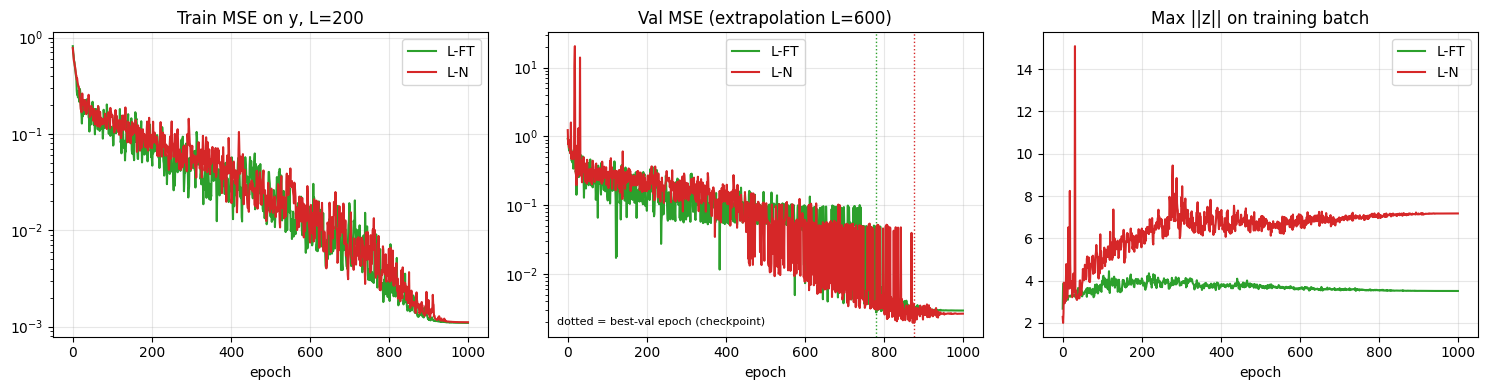

Best val (extrapolation) MSE [restored weights]:
  L-FT: 2.741e-03  @ epoch 780   diverged: None
  L-N : 1.936e-03  @ epoch 876   diverged: None


In [6]:
Wtr_d, Utr_d, Ytr_d = Wtr.to(device), Utr.to(device), Ytr.to(device)
Wva_d, Uva_d, Yva_d = Wva.to(device), Uva.to(device), Yva.to(device)

def train_one(model, n_epochs=120, lr=3e-3, batch=64, clip=1.0, label='model',
              ckpt_path=None, verbose=True):
    """Train rollout-MSE on y, checkpointing the *best* validation model.

    The weights at the epoch with the lowest validation extrapolation MSE are
    saved to `ckpt_path` (and the best epoch/val recorded in the history). The
    last epoch is not always the best on a long-horizon val metric, so call
    `model.load_state_dict(torch.load(ckpt_path))` afterwards to recover it.
    """
    model = model.to(device)
    if ckpt_path is None:
        ckpt_path = f'best_model-duffing-{label}.pth'
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    history = {'train': [], 'val_extrap': [], 'zmax': [], 'diverged_at': None,
               'best_val': float('inf'), 'best_epoch': None, 'ckpt_path': ckpt_path}
    diverged = False
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(Wtr_d.shape[0], device=device)
        ep_losses = []
        ep_zmax = 0.0
        for i in range(0, len(perm), batch):
            idx = perm[i:i+batch]
            w = Wtr_d[idx]; u = Utr_d[idx]; y = Ytr_d[idx]
            yhat, zs = rollout_y(model, w, u, L, h_dt)
            loss = ((yhat - y) ** 2).mean()
            if not torch.isfinite(loss):
                diverged = True
                history['diverged_at'] = epoch
                break
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            ep_losses.append(loss.item())
            with torch.no_grad():
                ep_zmax = max(ep_zmax, zs.norm(dim=-1).max().item())
        if diverged:
            if verbose: print(f'[{label}] diverged at epoch {epoch}')
            break
        sched.step()
        model.eval()
        with torch.no_grad():
            yhat_v, _ = rollout_y(model, Wva_d, Uva_d, L_eval, h_dt)
            val = ((yhat_v - Yva_d) ** 2).mean().item()
        history['train'].append(float(np.mean(ep_losses)))
        history['val_extrap'].append(val)
        history['zmax'].append(ep_zmax)
        # --- checkpoint the best-val model ---
        if np.isfinite(val) and val < history['best_val']:
            history['best_val'] = val
            history['best_epoch'] = epoch
            torch.save(model.state_dict(), ckpt_path)
        if verbose and (epoch % 10 == 0 or epoch == n_epochs - 1):
            print(f'[{label}] ep {epoch:3d}  train {history["train"][-1]:.3e}  '
                  f'val(L={L_eval}) {val:.3e}  zmax {ep_zmax:.2f}  '
                  f'({time.time()-t0:.1f}s)')
    if verbose and history['best_epoch'] is not None:
        print(f'[{label}] best val {history["best_val"]:.3e} @ epoch '
              f'{history["best_epoch"]} -> saved {ckpt_path}')
    return model, history


def restore_best(model, hist, label):
    """Load the best-val checkpoint back into `model` (in place)."""
    cp = hist.get('ckpt_path')
    if hist.get('best_epoch') is None or cp is None or not pathlib.Path(cp).exists():
        print(f'[{label}] no checkpoint to restore (diverged / never improved) '
              f'- keeping final-epoch weights')
        return model
    model.load_state_dict(torch.load(cp, map_location=device))
    model.eval()
    print(f'[{label}] restored best-val weights from epoch {hist["best_epoch"]} '
          f'(val {hist["best_val"]:.3e})')
    return model


torch.manual_seed(0); np.random.seed(0)
lft = build_lft(m=4, sigma_min=0.1)
lft, h_lft = train_one(lft, n_epochs=1000, label='L-FT',
                       ckpt_path='best_model-duffing-lft-1000.pth')

torch.manual_seed(0); np.random.seed(0)
ln = build_ln(m=4, hidden=128, depth=4)
ln, h_ln = train_one(ln, n_epochs=1000, label='L-N',
                      ckpt_path='best_model-duffing-ln-1000.pth')

# Restore each model to its best-val checkpoint before all evaluation below.
lft = restore_best(lft, h_lft, 'L-FT')
ln  = restore_best(ln,  h_ln,  'L-N')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for hist, lbl, c in [(h_lft, 'L-FT', 'C2'), (h_ln, 'L-N', 'C3')]:
    axes[0].semilogy(hist['train'],      label=lbl, color=c)
    axes[1].semilogy(np.maximum(hist['val_extrap'], 1e-12), label=lbl, color=c)
    axes[2].plot(hist['zmax'],           label=lbl, color=c)
    if hist['best_epoch'] is not None:
        axes[1].axvline(hist['best_epoch'], color=c, ls=':', lw=1.0)
axes[0].set_title(f'Train MSE on y, L={L}'); axes[0].set_xlabel('epoch')
axes[1].set_title(f'Val MSE (extrapolation L={L_eval})'); axes[1].set_xlabel('epoch')
axes[1].text(0.02, 0.04, 'dotted = best-val epoch (checkpoint)', transform=axes[1].transAxes, fontsize=8)
axes[2].set_title('Max ||z|| on training batch'); axes[2].set_xlabel('epoch')
for ax in axes: ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Best val (extrapolation) MSE [restored weights]:')
print(f'  L-FT: {h_lft["best_val"]:.3e}  @ epoch {h_lft["best_epoch"]}   diverged: {h_lft["diverged_at"]}')
print(f'  L-N : {h_ln ["best_val"]:.3e}  @ epoch {h_ln ["best_epoch"]}   diverged: {h_ln ["diverged_at"]}')

## 4. Reconstruction on held-out long rollouts

Encode the validation window, roll out for $L_{\mathrm{eval}}$ steps, decode and compare to the true $y$. The training horizon was $L = 200$; everything past that is *extrapolation*.

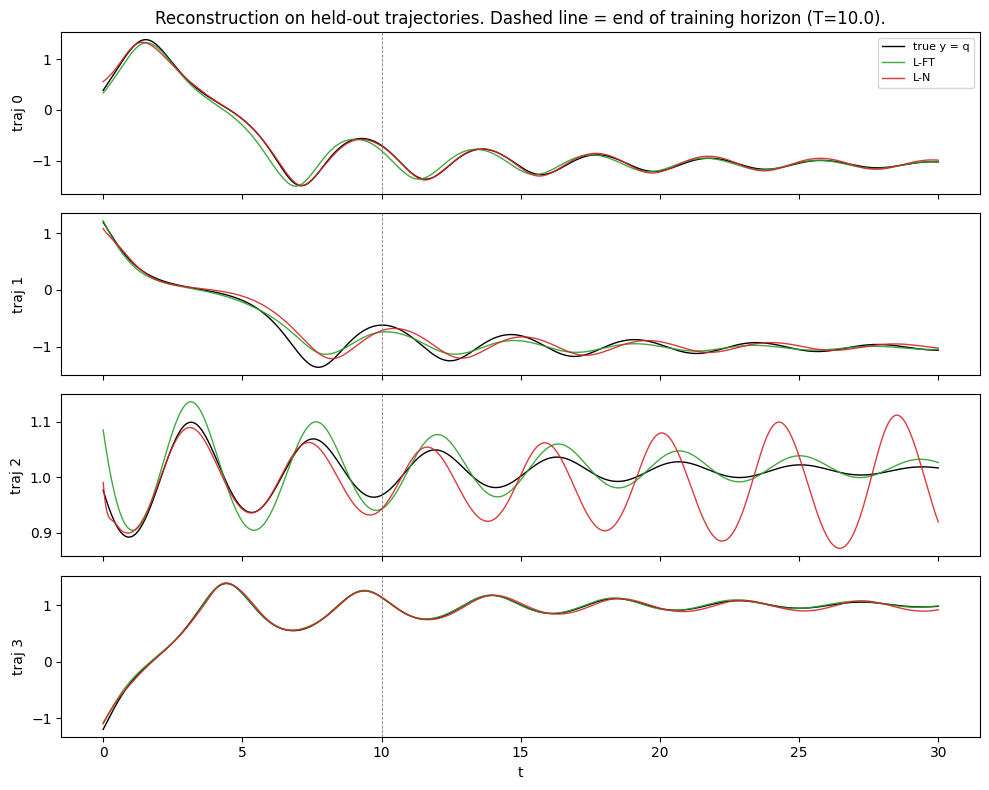

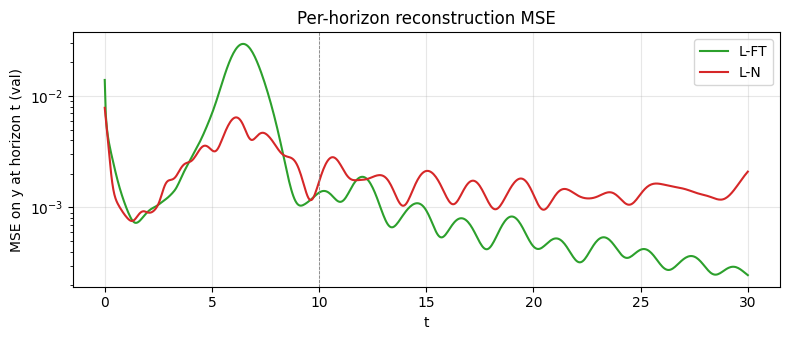

In [7]:
with torch.no_grad():
    Yhat_lft, Zhat_lft = rollout_y(lft, Wva_d, Uva_d, L_eval, h_dt)
    Yhat_ln,  Zhat_ln  = rollout_y(ln,  Wva_d, Uva_d, L_eval, h_dt)
Yhat_lft = Yhat_lft.cpu().numpy(); Yhat_ln = Yhat_ln.cpu().numpy()
Yva_np = Yva.numpy()
tline_e = np.arange(L_eval + 1) * h_dt
T_train = L * h_dt

n_show = 4
fig, axes = plt.subplots(n_show, 1, figsize=(10, 2.0 * n_show), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(tline_e, Yva_np[i],      'k',  lw=1.0, label='true y = q')
    ax.plot(tline_e, Yhat_lft[i],    'C2', lw=1.0, alpha=0.9, label='L-FT')
    if np.all(np.isfinite(Yhat_ln[i])):
        ax.plot(tline_e, Yhat_ln[i], 'C3', lw=1.0, alpha=0.9, label='L-N')
    ax.axvline(T_train, color='gray', lw=0.6, ls='--')
    ax.set_ylabel(f'traj {i}')
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)
        ax.set_title(f'Reconstruction on held-out trajectories. Dashed line = end of training horizon (T={T_train:.1f}).')
axes[-1].set_xlabel('t')
plt.tight_layout(); plt.show()

# Per-horizon MSE
mse_lft_t = ((Yhat_lft - Yva_np) ** 2).mean(axis=0)
mse_ln_t  = ((Yhat_ln  - Yva_np) ** 2).mean(axis=0)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.semilogy(tline_e, np.maximum(mse_lft_t, 1e-12), 'C2', label='L-FT')
ax.semilogy(tline_e, np.maximum(mse_ln_t,  1e-12), 'C3', label='L-N')
ax.axvline(T_train, color='gray', lw=0.6, ls='--')
ax.set_xlabel('t'); ax.set_ylabel('MSE on y at horizon t (val)')
ax.set_title('Per-horizon reconstruction MSE')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Implicit recovery of the hidden coordinate $\dot q$

If the latent state $\boldsymbol{z}$ is a faithful lift of the (unobserved) full state $\boldsymbol{x}$, then there should exist a *linear* projection $\boldsymbol{z} \mapsto \dot q$ that fits well on a held-out set. We solve a least-squares problem on the validation set,
$$\min_{\boldsymbol{w}, b}\ \sum_{i, t} \left(\boldsymbol{w}^\top \boldsymbol{z}_t^{(i)} + b - \dot q_t^{(i)}\right)^2,$$
and report the $R^2$. This is *not* used during training — it is a post-hoc probe of how much of the missing coordinate is encoded in the latent state.

The point is qualitative: a structural prior that biases the model toward dynamics with the right coarse geometry (hyperbolic equilibria, contractive linearisations) ought to recover $\dot q$ better than an unstructured fit.

In [8]:
def linear_recovery_r2(Z, target):
    """Z: (N, m) latent samples. target: (N,) hidden coord. Returns R^2 with bias term."""
    Z = np.asarray(Z); t = np.asarray(target)
    Zb = np.concatenate([Z, np.ones((Z.shape[0], 1))], axis=1)
    w, *_ = np.linalg.lstsq(Zb, t, rcond=None)
    pred = Zb @ w
    ss_res = np.sum((t - pred) ** 2)
    ss_tot = np.sum((t - t.mean()) ** 2) + 1e-12
    return 1.0 - ss_res / ss_tot, w

Zlft = Zhat_lft.cpu().numpy().reshape(-1, 4)
Zln  = Zhat_ln .cpu().numpy().reshape(-1, 4)
Qdot = Xva[..., 1].numpy().reshape(-1)
Q    = Xva[..., 0].numpy().reshape(-1)

# split half/half for fit / eval
N = Zlft.shape[0]
perm = np.random.default_rng(7).permutation(N)
fit_idx, eval_idx = perm[:N//2], perm[N//2:]
for name, Z in [('L-FT', Zlft), ('L-N', Zln)]:
    if not np.all(np.isfinite(Z)):
        print(f'  {name}: NaN/Inf in latent -> skip')
        continue
    r2_q,    w_q    = linear_recovery_r2(Z[fit_idx],    Q   [fit_idx])
    r2_qd,   w_qd   = linear_recovery_r2(Z[fit_idx],    Qdot[fit_idx])
    # eval
    pq    = np.concatenate([Z[eval_idx], np.ones((len(eval_idx),1))],1) @ w_q
    pqd   = np.concatenate([Z[eval_idx], np.ones((len(eval_idx),1))],1) @ w_qd
    r2e_q  = 1 - np.sum((Q   [eval_idx]-pq )**2) / (np.sum((Q   [eval_idx]-Q   [eval_idx].mean())**2)+1e-12)
    r2e_qd = 1 - np.sum((Qdot[eval_idx]-pqd)**2) / (np.sum((Qdot[eval_idx]-Qdot[eval_idx].mean())**2)+1e-12)
    print(f'  {name}: linear R^2 to q  = {r2e_q:.3f} (fit {r2_q:.3f})   '
          f'linear R^2 to q_dot = {r2e_qd:.3f} (fit {r2_qd:.3f})')

  L-FT: linear R^2 to q  = 0.997 (fit 0.997)   linear R^2 to q_dot = 0.888 (fit 0.886)
  L-N: linear R^2 to q  = 0.998 (fit 0.998)   linear R^2 to q_dot = 0.163 (fit 0.156)


## 6. Latent-space geometry

Project latent trajectories to the leading 2 PCA components and overlay the (true) phase portrait. With the FTNODE structural prior, the latent flow should look like a contraction-to-fixed-points picture; without it, it could still fit the observed projection but may carry junk in directions orthogonal to the decoder.

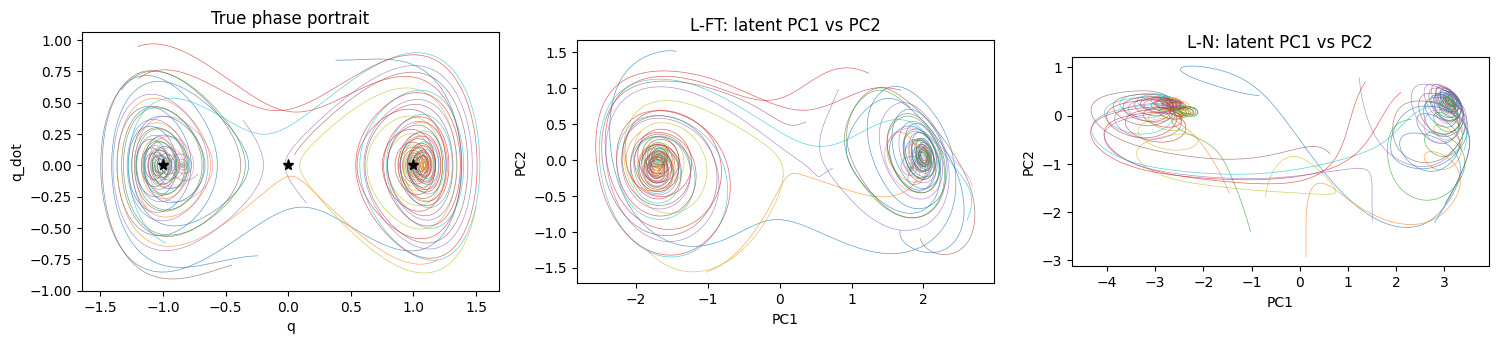

In [9]:
def pca_2d(Z):
    Zc = Z - Z.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Zc, full_matrices=False)
    return Zc @ Vt[:2].T, Vt[:2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].set_title('True phase portrait')
for i in range(min(16, Xva.shape[0])):
    axes[0].plot(Xva[i, :, 0].numpy(), Xva[i, :, 1].numpy(), lw=0.5, alpha=0.7)
for xe in equilibria(0.0): axes[0].plot(*xe, 'k*', ms=8)
axes[0].set_xlabel('q'); axes[0].set_ylabel('q_dot'); axes[0].set_aspect('equal')

for ax, Z, name in [(axes[1], Zhat_lft.cpu().numpy(), 'L-FT'),
                    (axes[2], Zhat_ln .cpu().numpy(), 'L-N')]:
    Zflat = Z.reshape(-1, Z.shape[-1])
    if not np.all(np.isfinite(Zflat)):
        ax.set_title(f'{name}: latent diverged')
        continue
    proj, basis = pca_2d(Zflat)
    proj = proj.reshape(Z.shape[0], Z.shape[1], 2)
    for i in range(min(16, Z.shape[0])):
        ax.plot(proj[i, :, 0], proj[i, :, 1], lw=0.5, alpha=0.7)
    ax.set_title(f'{name}: latent PC1 vs PC2')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

# Spectral Analysis

## 7. Split-term diagnostics for the Latent FTNODE

The structured latent vector field factorises as
$$\boldsymbol{F}_\theta(\boldsymbol{z},u)=\underbrace{\boldsymbol{A}_\theta(\boldsymbol{z})}_{\text{linearised flow}}\,\bigl(\boldsymbol{z}-\underbrace{\boldsymbol{g}_\theta(\boldsymbol{z},u)}_{\text{equilibrium map}}\bigr),\qquad \boldsymbol{A}_\theta=-(\boldsymbol{L}\boldsymbol{L}^\top+\sigma_{\min}\boldsymbol{I})+(\boldsymbol{M}-\boldsymbol{M}^\top).$$

The two factors carry the model's inductive bias and are individually interpretable, so we inspect them directly (this analysis applies only to the **L-FT** model — the plain L-N has no such split). We evaluate over two state sets:

- **rollout** — the latent states actually visited along the held-out validation rollouts (what governs the model's behaviour);
- **box** — a uniform sample of the latent box $[-R_z,R_z]^m$ (the globally learned field, independent of any trajectory).

For each we check:
- **Spectrum of $\boldsymbol{A}(\boldsymbol{z})$.** Since $\operatorname{sym}\boldsymbol{A}\preceq-\sigma_{\min}\boldsymbol{I}$ by construction, every eigenvalue must satisfy $\operatorname{Re}\lambda(\boldsymbol{A})\le-\sigma_{\min}$ (field-of-values bound) — a numerical confirmation of the contraction prior, plus the distribution of decay rates / oscillation.
- **Image of $\boldsymbol{g}$.** The equilibrium map decoded into observation space, $\psi(\boldsymbol{g}(\boldsymbol{z},u))$, should trace the *true* Duffing equilibrium manifold $q^3-q-u=0$; and each latent coordinate should respect the $\pm R_g$ box bound.

In [10]:
# Split-term analysis targets the structured model (LatentFTNODE).
dyn = lft.dynamics
assert isinstance(dyn, LatentFTNODE), 'split-term analysis is for the L-FT model'
m = dyn.m
sigma_min = float(dyn.sigma_min)
R_g = float(dyn.R_g)

# --- Eval set 1: latent states visited along the held-out rollouts (best L-FT) ---
with torch.no_grad():
    _, Z_roll = rollout_y(lft, Wva_d, Uva_d, L_eval, h_dt)        # (B, L_eval+1, m)
B_roll, T_roll = Z_roll.shape[0], Z_roll.shape[1]
Z_roll_flat = Z_roll.reshape(-1, m)                               # (N1, m)
U_roll_flat = Uva_d.view(-1, 1).expand(B_roll, T_roll).reshape(-1)  # (N1,) matched per-traj u

# --- Eval set 2: uniform sample of the latent box [-R_z, R_z]^m, random u ---
n_box = 4000
g_t = torch.Generator(device='cpu').manual_seed(0)
Z_box = ((2 * torch.rand(n_box, m, generator=g_t) - 1) * R_LATENT).to(device)
U_box = ((2 * torch.rand(n_box, generator=g_t) - 1) * u_range).to(device)

finite_roll = bool(torch.isfinite(Z_roll_flat).all())
print(f'rollout latent states : {Z_roll_flat.shape[0]:6d}  (finite: {finite_roll})')
print(f'box-sampled states    : {Z_box.shape[0]:6d}  in [-{R_LATENT}, {R_LATENT}]^{m},  '
      f'u in [-{u_range}, {u_range}]')
print(f'sigma_min = {sigma_min},  R_g = {R_g}')

rollout latent states :  38464  (finite: True)
box-sampled states    :   4000  in [-2.0, 2.0]^4,  u in [-0.25, 0.25]
sigma_min = 0.1,  R_g = 2.0


### 7.1 Spectrum of $\boldsymbol{A}(\boldsymbol{z})$ — contraction check

$\boldsymbol{A}(\boldsymbol{z})=-(\boldsymbol{L}\boldsymbol{L}^\top+\sigma_{\min}\boldsymbol{I})+(\boldsymbol{M}-\boldsymbol{M}^\top)$. The skew part $(\boldsymbol{M}-\boldsymbol{M}^\top)$ moves eigenvalues off the real axis (rotation/oscillation) but cannot change the symmetric part, so the field-of-values bound $\operatorname{Re}\lambda(\boldsymbol{A})\le\lambda_{\max}(\operatorname{sym}\boldsymbol{A})\le-\sigma_{\min}$ must hold at every state. We confirm this numerically and look at how fast / how oscillatory the learned linearisation is.

Eigenvalues of A(z)  [sym(A) <= -sigma_min I  =>  Re(lambda) <= -sigma_min]:
  [rollout] Re(lambda A): min -26.405  max -0.104  (<= -sigma_min=-0.100?  True)
            max eig(sym A) = -0.100   oscillatory modes |Im|>0: 59.8%  (|Im| max 1.857)
  [box    ] Re(lambda A): min -651.255  max -0.101  (<= -sigma_min=-0.100?  True)
            max eig(sym A) = -0.100   oscillatory modes |Im|>0: 46.0%  (|Im| max 2.081)


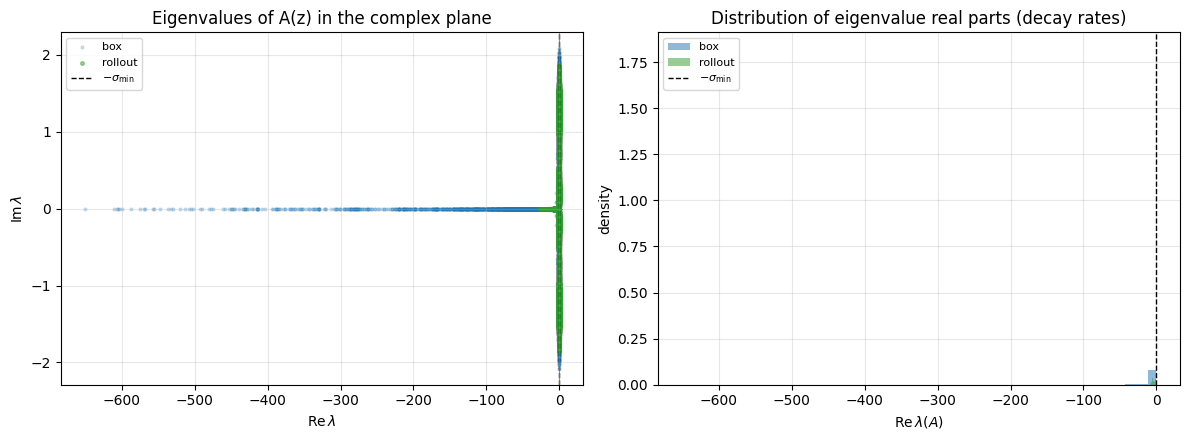

In [11]:
@torch.no_grad()
def eigvals_A(dyn, Z, chunk=2048):
    out = []
    for i in range(0, Z.shape[0], chunk):
        A = dyn.A(Z[i:i+chunk])
        out.append(torch.linalg.eigvals(A).cpu())      # (b, m) complex
    return torch.cat(out, 0).numpy()

@torch.no_grad()
def eigvals_symA(dyn, Z, chunk=2048):
    out = []
    for i in range(0, Z.shape[0], chunk):
        A = dyn.A(Z[i:i+chunk])
        S = 0.5 * (A + A.transpose(1, 2))
        out.append(torch.linalg.eigvalsh(S).cpu())      # (b, m) real, ascending
    return torch.cat(out, 0).numpy()

ev_roll = eigvals_A(dyn, Z_roll_flat)        # (N1, m) complex
ev_box  = eigvals_A(dyn, Z_box)              # (N2, m) complex
sev_roll = eigvals_symA(dyn, Z_roll_flat)    # (N1, m) real
sev_box  = eigvals_symA(dyn, Z_box)

def _summ(ev, sev, name):
    re = ev.real
    print(f'  [{name:7s}] Re(lambda A): min {re.min():+.3f}  max {re.max():+.3f}  '
          f'(<= -sigma_min={-sigma_min:+.3f}?  {bool(re.max() <= -sigma_min + 1e-4)})')
    print(f'            max eig(sym A) = {sev.max():+.3f}   '
          f'oscillatory modes |Im|>0: {100*np.mean(np.abs(ev.imag) > 1e-6):.1f}%  '
          f'(|Im| max {np.abs(ev.imag).max():.3f})')

print('Eigenvalues of A(z)  [sym(A) <= -sigma_min I  =>  Re(lambda) <= -sigma_min]:')
_summ(ev_roll, sev_roll, 'rollout')
_summ(ev_box,  sev_box,  'box')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.scatter(ev_box.real.ravel(),  ev_box.imag.ravel(),  s=4, alpha=0.20, color='C0', label='box')
ax.scatter(ev_roll.real.ravel(), ev_roll.imag.ravel(), s=7, alpha=0.45, color='C2', label='rollout')
ax.axvline(-sigma_min, color='k', ls='--', lw=1, label=r'$-\sigma_{\min}$')
ax.axvline(0.0, color='gray', lw=0.6)
ax.set_xlabel(r'$\mathrm{Re}\,\lambda$'); ax.set_ylabel(r'$\mathrm{Im}\,\lambda$')
ax.set_title('Eigenvalues of A(z) in the complex plane')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(ev_box.real.ravel(),  bins=60, density=True, alpha=0.5, color='C0', label='box')
ax.hist(ev_roll.real.ravel(), bins=60, density=True, alpha=0.5, color='C2', label='rollout')
ax.axvline(-sigma_min, color='k', ls='--', lw=1, label=r'$-\sigma_{\min}$')
ax.set_xlabel(r'$\mathrm{Re}\,\lambda(A)$'); ax.set_ylabel('density')
ax.set_title('Distribution of eigenvalue real parts (decay rates)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 7.2 Image of $\boldsymbol{g}$ — the learned equilibrium map

$\boldsymbol{g}_\theta(\boldsymbol{z},u)=R_g\tanh(\mathrm{MLP}([\boldsymbol{z},u]))$ is the (bounded) equilibrium map: the latent flow contracts toward $\boldsymbol{z}=\boldsymbol{g}$. Decoding it, $\psi(\boldsymbol{g}(\boldsymbol{z},u))$ is the model's predicted *observable* equilibrium $q^*$ as a function of the control $u$. If the latent state-space model has identified the plant, this image should track the true Duffing equilibrium manifold (roots of $q^3-q-u=0$: two sinks + a saddle in the bistable window). We also histogram each latent coordinate of the image to confirm it stays within the $\pm R_g$ box.

Image of g (equilibrium map) per latent coordinate  (bounded by R_g = 2.00):
  g[0]: min -0.535  max +1.317  mean +0.251  std 0.498
  g[1]: min -1.791  max +1.385  mean -0.093  std 1.157
  g[2]: min -0.332  max +0.720  mean +0.130  std 0.175
  g[3]: min -1.716  max +1.699  mean -0.119  std 0.903
  max |g|_inf (box) = 1.791   (must be <= R_g = 2.0)
  decoded q*=psi(g): box [-1.354, +1.363], rollout [-1.270, +1.277]
  true Duffing equilibria span q in [-1.107, +1.107] over the u-range


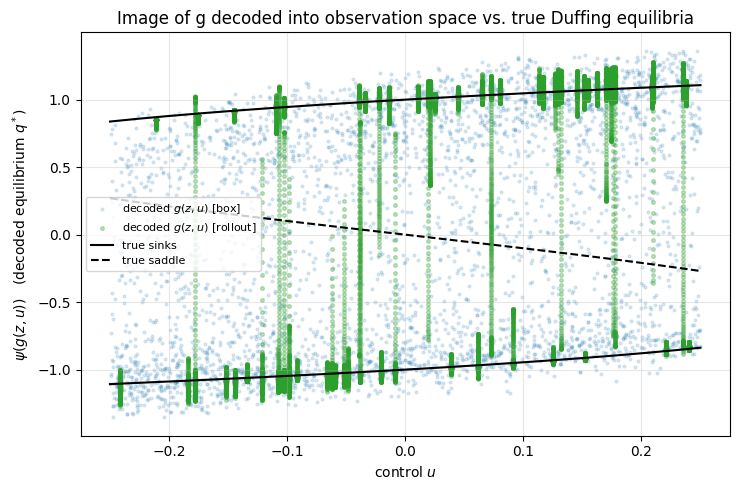

In [12]:
@torch.no_grad()
def g_image(dyn, Z, U):
    return dyn.g(Z, U)                                  # (N, m)

G_roll = g_image(dyn, Z_roll_flat, U_roll_flat)
G_box  = g_image(dyn, Z_box, U_box)
with torch.no_grad():
    qg_roll = lft.decode(G_roll).cpu().numpy()          # decoded observable equilibrium q*
    qg_box  = lft.decode(G_box ).cpu().numpy()
G_roll_np, G_box_np = G_roll.cpu().numpy(), G_box.cpu().numpy()
U_roll_np, U_box_np = U_roll_flat.cpu().numpy(), U_box.cpu().numpy()

# True Duffing equilibrium manifold over the training u-range: roots of q^3 - q - u = 0.
u_grid = np.linspace(-u_range, u_range, 200)
eqs_per_u = [equilibria(u) for u in u_grid]
assert min(len(e) for e in eqs_per_u) == max(len(e) for e in eqs_per_u) == 3, \
    'expected 3 equilibria across the u-range (bistable window)'
branches = np.array([[e[0] for e in eqs] for eqs in eqs_per_u])   # (200, 3): left sink, saddle, right sink
true_lo, true_hi = branches.min(), branches.max()

print('Image of g (equilibrium map) per latent coordinate  (bounded by R_g = %.2f):' % R_g)
for k in range(m):
    col = G_box_np[:, k]
    print(f'  g[{k}]: min {col.min():+.3f}  max {col.max():+.3f}  '
          f'mean {col.mean():+.3f}  std {col.std():.3f}')
print(f'  max |g|_inf (box) = {np.abs(G_box_np).max():.3f}   (must be <= R_g = {R_g})')
print(f'  decoded q*=psi(g): box [{qg_box.min():+.3f}, {qg_box.max():+.3f}], '
      f'rollout [{qg_roll.min():+.3f}, {qg_roll.max():+.3f}]')
print(f'  true Duffing equilibria span q in [{true_lo:+.3f}, {true_hi:+.3f}] over the u-range')

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(U_box_np,  qg_box,  s=4, alpha=0.15, color='C0', label=r'decoded $g(z,u)$ [box]')
ax.scatter(U_roll_np, qg_roll, s=7, alpha=0.30, color='C2', label=r'decoded $g(z,u)$ [rollout]')
ax.plot(u_grid, branches[:, 0], 'k-',  lw=1.5, label='true sinks')
ax.plot(u_grid, branches[:, 2], 'k-',  lw=1.5)
ax.plot(u_grid, branches[:, 1], 'k--', lw=1.5, label='true saddle')
ax.set_xlabel('control $u$'); ax.set_ylabel(r'$\psi(g(z,u))$   (decoded equilibrium $q^*$)')
ax.set_title('Image of g decoded into observation space vs. true Duffing equilibria')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

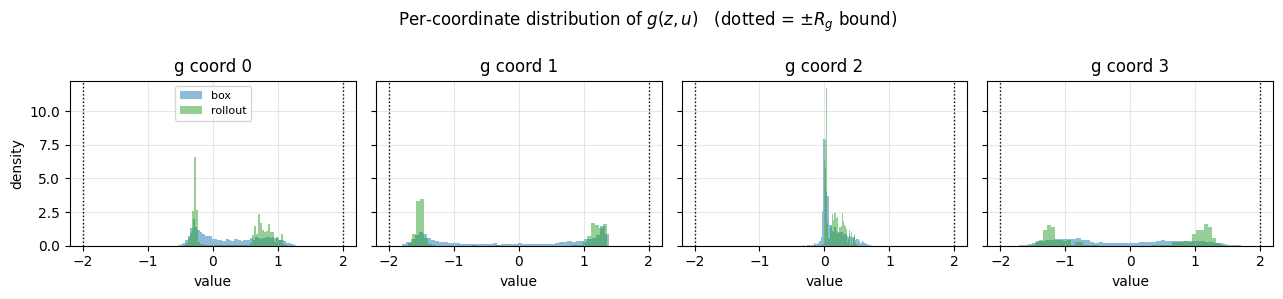

In [13]:
# Per-coordinate distribution of the equilibrium map (one panel per latent dim).
fig, axes = plt.subplots(1, m, figsize=(3.2 * m, 3), sharey=True)
axes = np.atleast_1d(axes)
for k in range(m):
    ax = axes[k]
    ax.hist(G_box_np[:, k],  bins=50, density=True, alpha=0.5, color='C0', label='box')
    ax.hist(G_roll_np[:, k], bins=50, density=True, alpha=0.5, color='C2', label='rollout')
    ax.axvline(-R_g, color='k', ls=':', lw=1); ax.axvline(R_g, color='k', ls=':', lw=1)
    ax.set_title(f'g coord {k}'); ax.set_xlabel('value'); ax.grid(alpha=0.3)
    if k == 0:
        ax.set_ylabel('density'); ax.legend(fontsize=8)
fig.suptitle(r'Per-coordinate distribution of $g(z,u)$   (dotted = $\pm R_g$ bound)')
plt.tight_layout(); plt.show()